# TF-IDF Analysis

**Workflow**: Text → TF-IDF → TruncatedSVD → LogReg → 5-Fold CV

**Strategy**:
1. Tìm dim giữ được 80% variance
2. Upper bound = min(dim_80%, 2000)
3. Coarse search: step=100
4. Fine search: step=10

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

## 1. Load Data

In [2]:
df = pd.read_csv(PROJECT_ROOT / 'data' / 'encoded' / 'final_data_shuffled.csv')
texts = df['text_tfidf'].fillna('').tolist()
labels = df['label'].values
print(f"Samples: {len(texts)}, Labels: {dict(pd.Series(labels).value_counts())}")

Samples: 4736, Labels: {0: 3929, 1: 807}


## 2. Create TF-IDF Vectors

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_df=0.95,
    min_df=2,
    sublinear_tf=True
)

X_tfidf = vectorizer.fit_transform(texts)
ORIGINAL_DIM = X_tfidf.shape[1]
print(f"TF-IDF shape: {X_tfidf.shape}")
print(f"Sparsity: {1 - X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1]):.2%}")

TF-IDF shape: (4736, 73955)
Sparsity: 99.82%


## 3. Tìm Upper Bound (80% variance hoặc max 2000)

In [4]:
from sklearn.decomposition import TruncatedSVD

# Fit SVD với số components lớn để xem cumulative variance
n_test = min(3000, ORIGINAL_DIM - 1)
svd_test = TruncatedSVD(n_components=n_test, random_state=42)
svd_test.fit(X_tfidf)

# Tìm dim giữ được 80% variance
cumvar = np.cumsum(svd_test.explained_variance_ratio_)
dim_80 = np.searchsorted(cumvar, 0.80) + 1
print(f"Dim giữ 80% variance: {dim_80}")

# Upper bound = min(dim_80, 2000)
UPPER_BOUND = min(dim_80, 2000)
print(f"Upper bound for search: {UPPER_BOUND}")

Dim giữ 80% variance: 2690
Upper bound for search: 2000


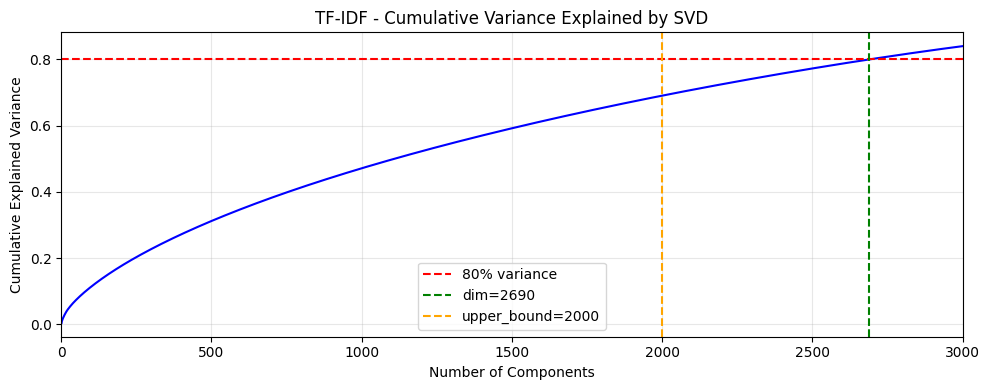

In [5]:
# Plot variance explained
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, len(cumvar)+1), cumvar, 'b-')
ax.axhline(y=0.80, color='r', linestyle='--', label='80% variance')
ax.axvline(x=dim_80, color='g', linestyle='--', label=f'dim={dim_80}')
ax.axvline(x=UPPER_BOUND, color='orange', linestyle='--', label=f'upper_bound={UPPER_BOUND}')
ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('TF-IDF - Cumulative Variance Explained by SVD')
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_xlim(0, min(3000, ORIGINAL_DIM))
plt.tight_layout(); plt.show()

## 4. Evaluation Function

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler

def evaluate_dim_svd(X_sparse, y, dim):
    """Luôn giảm chiều từ X_sparse gốc"""
    svd = TruncatedSVD(n_components=dim, random_state=42)
    X_r = svd.fit_transform(X_sparse)
    var = svd.explained_variance_ratio_.sum()
    
    X_s = StandardScaler().fit_transform(X_r)
    clf = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    auc = cross_val_score(clf, X_s, y, cv=cv, scoring='roc_auc')
    f1 = cross_val_score(clf, X_s, y, cv=cv, scoring='f1')
    prec = cross_val_score(clf, X_s, y, cv=cv, scoring='precision')
    rec = cross_val_score(clf, X_s, y, cv=cv, scoring='recall')
    return {'dim': dim, 'var': var,
            'auc_mean': auc.mean(), 'auc_std': auc.std(),
            'f1_mean': f1.mean(), 'f1_std': f1.std(),
            'prec_mean': prec.mean(), 'prec_std': prec.std(),
            'rec_mean': rec.mean(), 'rec_std': rec.std()}

def plot_metrics(df_results, title_prefix, x_col='dim'):
    metrics = [('auc', 'AUC-ROC'), ('f1', 'F1'), ('prec', 'Precision'), ('rec', 'Recall')]
    df_plot = df_results.sort_values(x_col)
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    for ax, (m, name) in zip(axes.flat, metrics):
        ax.errorbar(df_plot[x_col], df_plot[f'{m}_mean'], yerr=df_plot[f'{m}_std'], marker='o', capsize=3)
        ax.set_xlabel('Dimension'); ax.set_ylabel(name)
        ax.set_title(f'{title_prefix} - {name}', fontweight='bold')
        ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
    
    fig, ax = plt.subplots(figsize=(10, 5))
    for m, name in metrics:
        ax.errorbar(df_plot[x_col], df_plot[f'{m}_mean'], yerr=df_plot[f'{m}_std'], marker='o', capsize=3, label=name)
    ax.set_xlabel('Dimension'); ax.set_ylabel('Score')
    ax.set_title(f'{title_prefix} - All Metrics', fontweight='bold')
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

## 5. Coarse Search (Step=100)

In [7]:
# Coarse dims: từ UPPER_BOUND xuống 100, step=100
COARSE_DIMS = list(range(UPPER_BOUND, 99, -100))
if COARSE_DIMS[-1] != 100:
    COARSE_DIMS.append(100)
print(f"Coarse search dims: {COARSE_DIMS}")

coarse_results = []
for dim in tqdm(COARSE_DIMS, desc="Coarse Search"):
    r = evaluate_dim_svd(X_tfidf, labels, dim)
    coarse_results.append(r)
    print(f"Dim {dim:4d}: AUC={r['auc_mean']:.4f}, F1={r['f1_mean']:.4f}, Prec={r['prec_mean']:.4f}, Rec={r['rec_mean']:.4f}, Var={r['var']:.2%}")

df_coarse = pd.DataFrame(coarse_results)
best_coarse = df_coarse.loc[df_coarse['auc_mean'].idxmax()]
print(f"\nBest coarse: dim={int(best_coarse['dim'])}, AUC={best_coarse['auc_mean']:.4f}, Var={best_coarse['var']:.2%}")

Coarse search dims: [2000, 1900, 1800, 1700, 1600, 1500, 1400, 1300, 1200, 1100, 1000, 900, 800, 700, 600, 500, 400, 300, 200, 100]


Coarse Search:   5%|▌         | 1/20 [01:11<22:31, 71.12s/it]

Dim 2000: AUC=0.7653, F1=0.4838, Prec=0.4483, Rec=0.5266, Var=68.44%


Coarse Search:  10%|█         | 2/20 [02:16<20:23, 67.97s/it]

Dim 1900: AUC=0.7787, F1=0.5029, Prec=0.4717, Rec=0.5402, Var=66.59%


...

Dim  300: AUC=0.8589, F1=0.5629, Prec=0.4554, Rec=0.7372, Var=22.32%


Coarse Search:  95%|█████████▌| 19/20 [10:58<00:11, 11.22s/it]

Dim  200: AUC=0.8660, F1=0.5661, Prec=0.4558, Rec=0.7471, Var=17.30%


Coarse Search: 100%|██████████| 20/20 [11:01<00:00, 33.08s/it]

Dim  100: AUC=0.8715, F1=0.5552, Prec=0.4404, Rec=0.7509, Var=11.17%

Best coarse: dim=100, AUC=0.8715, Var=11.17%


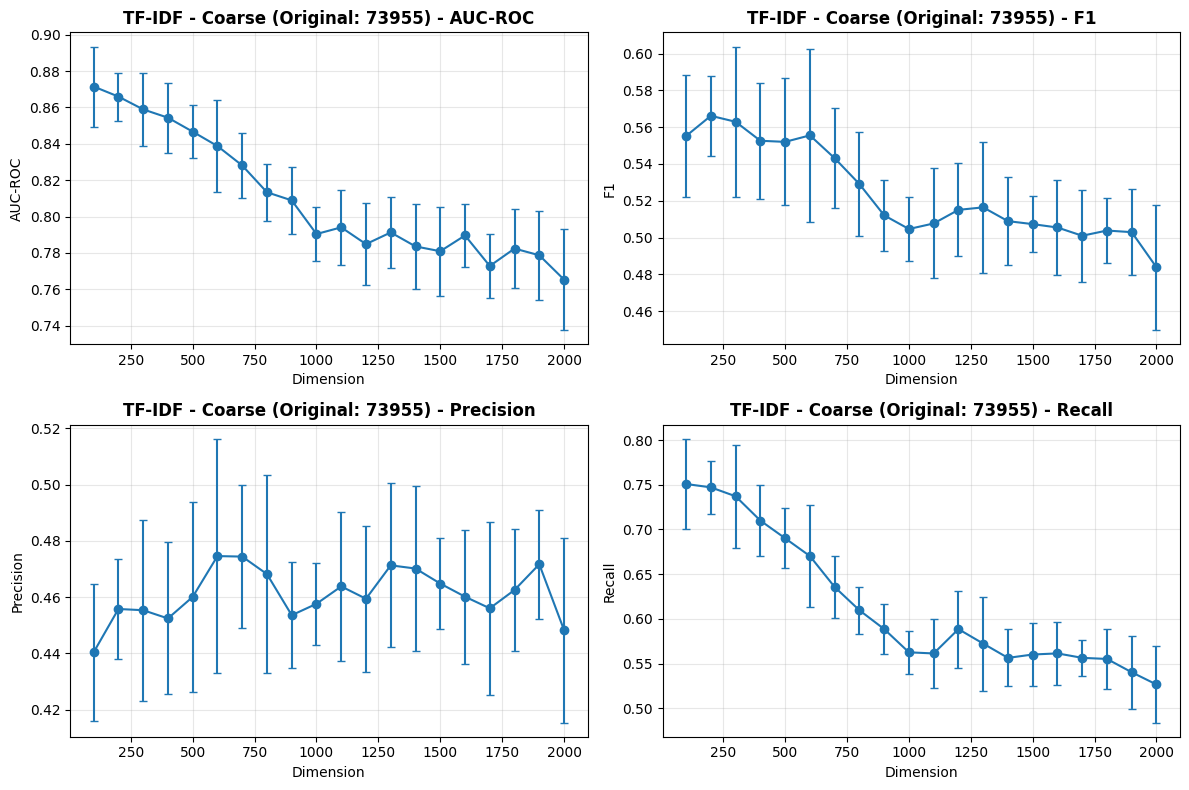

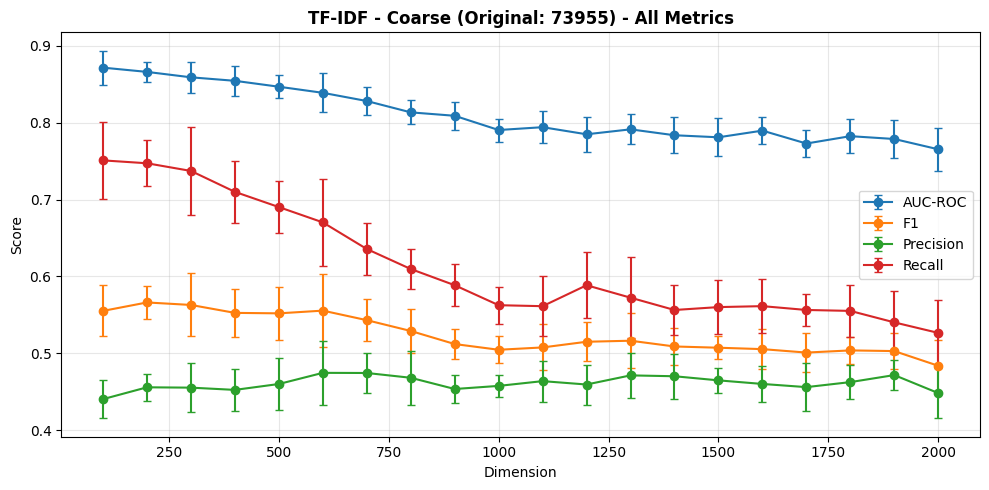

In [8]:
plot_metrics(df_coarse, f'TF-IDF - Coarse (Original: {ORIGINAL_DIM})')

## 6. Fine Search (Step=10)

In [9]:
best_dim = int(best_coarse['dim'])
fine_start = max(100, best_dim - 50)
fine_end = min(UPPER_BOUND, best_dim + 50)
FINE_DIMS = list(range(fine_start, fine_end + 1, 10))
print(f"Fine search range: {fine_start} to {fine_end}")
print(f"Fine dims: {FINE_DIMS}")

fine_results = []
for dim in tqdm(FINE_DIMS, desc="Fine Search"):
    r = evaluate_dim_svd(X_tfidf, labels, dim)
    fine_results.append(r)
    print(f"Dim {dim:4d}: AUC={r['auc_mean']:.4f}, F1={r['f1_mean']:.4f}, Prec={r['prec_mean']:.4f}, Rec={r['rec_mean']:.4f}, Var={r['var']:.2%}")

df_fine = pd.DataFrame(fine_results)
best_fine = df_fine.loc[df_fine['auc_mean'].idxmax()]
print(f"\nBest fine: dim={int(best_fine['dim'])}, AUC={best_fine['auc_mean']:.4f}, Var={best_fine['var']:.2%}")

Fine search range: 100 to 150
Fine dims: [100, 110, 120, 130, 140, 150]


Fine Search:  17%|█▋        | 1/6 [00:02<00:12,  2.58s/it]

Dim  100: AUC=0.8715, F1=0.5552, Prec=0.4404, Rec=0.7509, Var=11.17%


Fine Search:  33%|███▎      | 2/6 [00:05<00:10,  2.69s/it]

Dim  110: AUC=0.8680, F1=0.5637, Prec=0.4484, Rec=0.7595, Var=11.85%


...

Dim  130: AUC=0.8718, F1=0.5652, Prec=0.4510, Rec=0.7571, Var=13.17%


Fine Search:  83%|████████▎ | 5/6 [00:14<00:03,  3.07s/it]

Dim  140: AUC=0.8711, F1=0.5704, Prec=0.4549, Rec=0.7645, Var=13.80%


Fine Search: 100%|██████████| 6/6 [00:18<00:00,  3.05s/it]

Dim  150: AUC=0.8691, F1=0.5625, Prec=0.4482, Rec=0.7558, Var=14.41%

Best fine: dim=120, AUC=0.8725, Var=12.53%


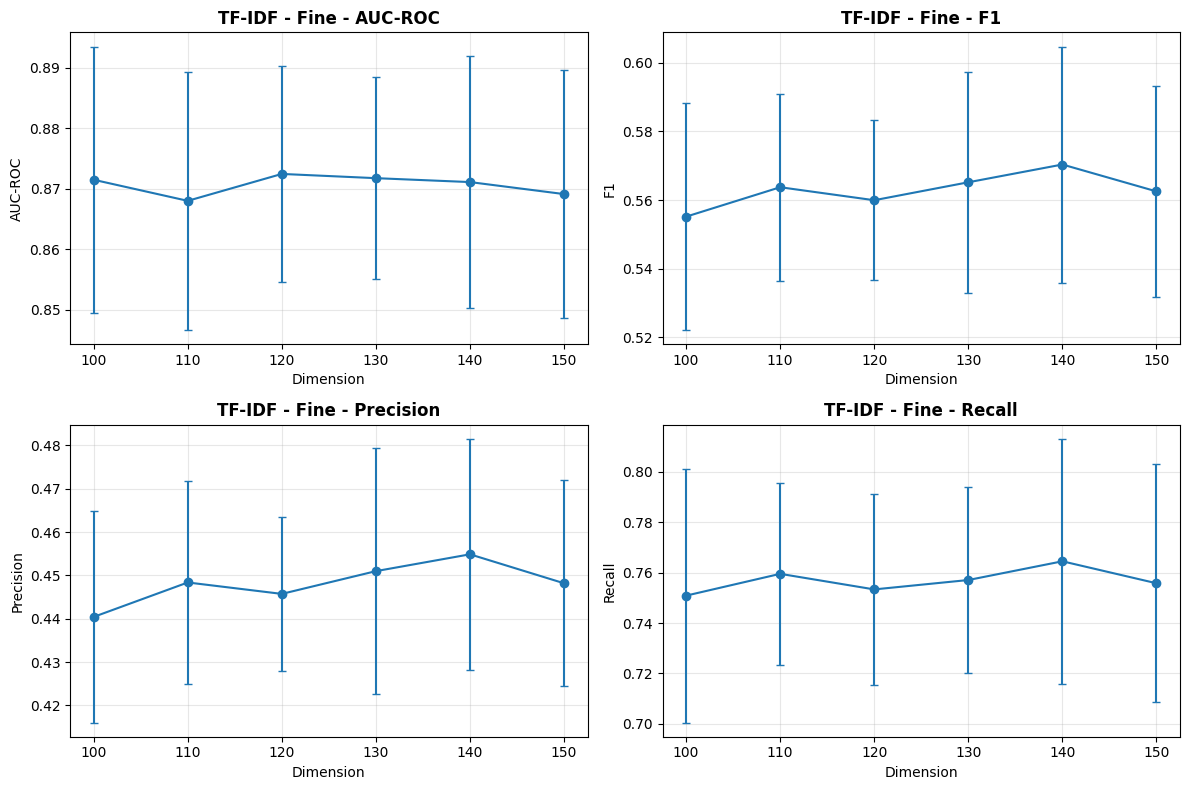

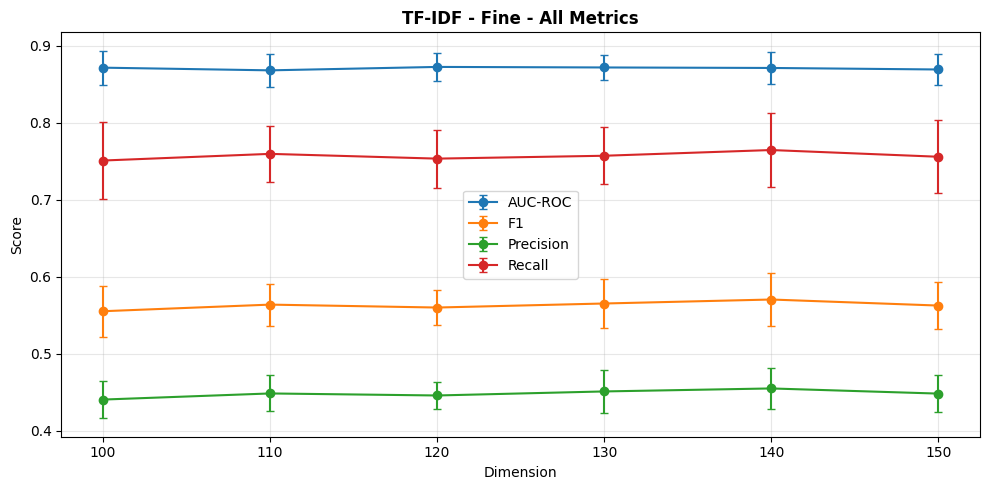

In [10]:
plot_metrics(df_fine, 'TF-IDF - Fine')

## 7. Final Results

In [11]:
OPTIMAL_DIM = int(best_fine['dim'])
print("="*70)
print(f"TF-IDF - OPTIMAL DIM: {OPTIMAL_DIM} (of {ORIGINAL_DIM})")
print("="*70)
print(f"AUC:       {best_fine['auc_mean']:.4f} ± {best_fine['auc_std']:.4f}")
print(f"F1:        {best_fine['f1_mean']:.4f} ± {best_fine['f1_std']:.4f}")
print(f"Precision: {best_fine['prec_mean']:.4f} ± {best_fine['prec_std']:.4f}")
print(f"Recall:    {best_fine['rec_mean']:.4f} ± {best_fine['rec_std']:.4f}")
print(f"Variance:  {best_fine['var']:.2%}")

TF-IDF - OPTIMAL DIM: 120 (of 73955)
AUC:       0.8725 ± 0.0178
F1:        0.5600 ± 0.0233
Precision: 0.4457 ± 0.0179
Recall:    0.7534 ± 0.0378
Variance:  12.53%


## 8. Save Optimal Embeddings

In [12]:
# Apply TruncatedSVD with optimal dimension (từ X_tfidf gốc)
svd_final = TruncatedSVD(n_components=OPTIMAL_DIM, random_state=42)
embeddings_optimal = svd_final.fit_transform(X_tfidf)
print(f"Reduced embeddings: {embeddings_optimal.shape}")
print(f"Variance retained: {svd_final.explained_variance_ratio_.sum():.2%}")

# Save - order matches final_data_shuffled.csv
OUTPUT_DIR = PROJECT_ROOT / 'data' / 'encoded' / 'tfidf'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
np.save(OUTPUT_DIR / 'tfidf_embeddings.npy', embeddings_optimal)
print(f"Saved to {OUTPUT_DIR / 'tfidf_embeddings.npy'}")
print(f"Shape: {embeddings_optimal.shape} (matches {len(df)} rows in final_data_shuffled.csv)")

Reduced embeddings: (4736, 120)
Variance retained: 12.53%
Saved to d:\Vietnamese-Fake-News-Detection\data\encoded\tfidf\tfidf_embeddings.npy
Shape: (4736, 120) (matches 4736 rows in final_data_shuffled.csv)
